In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from data_loader import load_raw

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
pd.set_option("display.max_columns", 50)

import os
os.makedirs("../figures/eda", exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)

Python: 3.10.12
pandas: 2.3.3


In [2]:
df = load_raw("../data/raw/frontier_2023.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (49869, 18)


,timestamp,s1_return_temp,s1_flow,s2_return_temp,s2_flow,s3_return_temp,s3_flow,avg_return_temp,supply_temp,total_flow,s1_heat,s2_heat,s3_heat,total_heat,compute_power,accessory_power,total_power,pue
0,2023-01-01 00:00:00,19.888889,844.8,20.388889,888.0,37.500000,1644.0,28.594369,16.277778,3376.8,0.713975,0.854399,8.165470,9.733845,11.168,0.6011,11.7691,1.053823
1,2023-01-01 00:10:00,22.944444,746.4,23.833333,787.2,36.444444,1430.4,29.695502,16.722222,2964.0,1.086940,1.310120,6.602401,8.999461,11.168,0.6011,11.7691,1.053823
2,2023-01-01 00:20:00,22.000000,823.2,22.444444,859.2,37.777778,1600.8,29.809129,18.666667,3283.2,0.642203,0.759660,7.159976,8.561839,11.464,0.6429,12.1069,1.056080
3,2023-01-01 00:30:00,25.000000,811.2,25.944444,852.0,38.000000,1569.6,31.560711,18.500000,3232.8,1.234042,1.484432,7.163284,9.881758,11.043,0.6097,11.6527,1.055211
4,2023-01-01 00:40:00,24.833333,672.0,25.888889,710.4,36.333333,1298.4,30.682881,17.722222,2680.8,1.118395,1.357802,5.655478,8.131675,11.043,0.6097,11.6527,1.055211


In [3]:
# Time-derived columns — safe to run multiple times
df["hour"]     = df["timestamp"].dt.hour
df["month"]    = df["timestamp"].dt.month
df["dow"]      = df["timestamp"].dt.dayofweek
df["dow_name"] = df["timestamp"].dt.day_name()

print("Time columns created:",
      [c for c in ["hour", "month", "dow", "dow_name"] if c in df.columns])

Time columns created: ['hour', 'month', 'dow', 'dow_name']


Columns with missing values: ['avg_return_temp']
avg_return_temp    122
dtype: int64


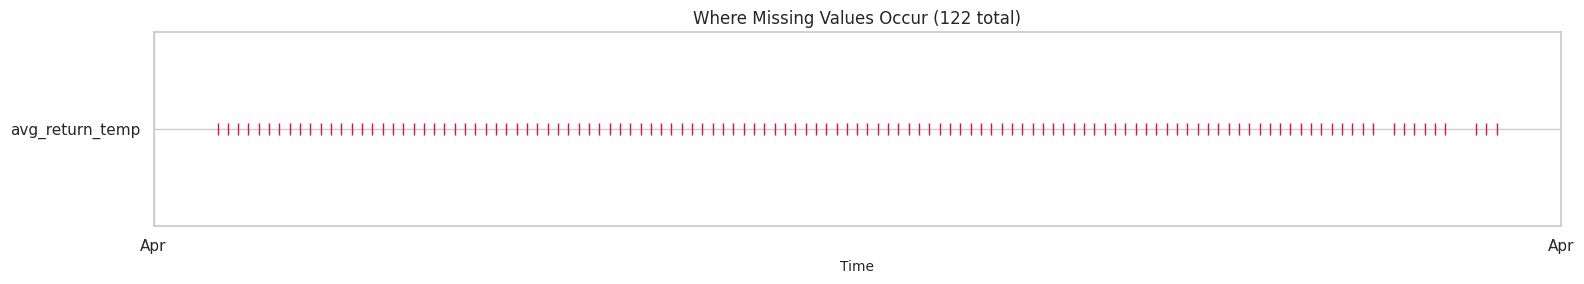

In [4]:
miss_cols = df.columns[df.isna().any()].tolist()
print("Columns with missing values:", miss_cols)
print(df[miss_cols].isna().sum())

if miss_cols:
    fig, ax = plt.subplots(figsize=(16, 3))
    for i, c in enumerate(miss_cols):
        missing_times = df.loc[df[c].isna(), "timestamp"]
        ax.plot(missing_times, [i] * len(missing_times), "|",
                ms=8, color="crimson", label=c)
    ax.set_yticks(range(len(miss_cols)))
    ax.set_yticklabels(miss_cols)
    ax.set_xlabel("Time")
    ax.set_title(f"Where Missing Values Occur ({df[miss_cols].isna().sum().sum()} total)")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    plt.tight_layout()
    plt.savefig("../figures/eda/01_missing_map.png", dpi=150)
    plt.show()
else:
    print("No missing values — skip this plot.")

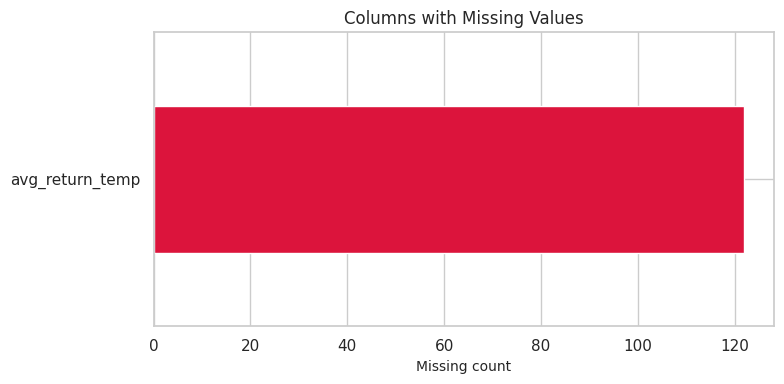

In [5]:
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss):
    fig, ax = plt.subplots(figsize=(8, 4))
    miss.plot(kind="barh", color="crimson", ax=ax)
    ax.set_title("Columns with Missing Values")
    ax.set_xlabel("Missing count")
    plt.tight_layout()
    plt.savefig("../figures/eda/02_missing_bar.png", dpi=150)
    plt.show()
else:
    print("No missing values.")

In [6]:
desc = df.describe().T
desc["range"] = desc["max"] - desc["min"]
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "range"]]
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,range
timestamp,49869,2023-07-04 04:11:23.703823360,NaN,2023-01-01 00:00:00,2023-03-29 14:00:00,2023-07-10 05:10:00,2023-10-06 10:00:00,2023-12-31 23:50:00,364 days 23:50:00
s1_return_temp,49869.0,28.249751,6.859404,7.277778,23.166667,30.888889,32.944444,44.722222,37.444444
s1_flow,49869.0,936.904735,324.643302,0.0,698.4,820.8,1174.816799,2965.6008,2965.6008
s2_return_temp,49869.0,28.422468,6.665847,7.222222,23.888889,30.888889,32.888889,65.870389,58.648167
s2_flow,49869.0,990.316661,339.787269,0.0,739.2,868.8,1238.4,1670.4,1670.4
s3_return_temp,49869.0,34.160958,3.518083,7.666667,32.111111,33.777778,36.055556,47.5,39.833333
s3_flow,49869.0,1904.910891,718.493215,0.0,1377.6,1584.0,2591.730362,3403.2,3403.2
avg_return_temp,49747.0,31.198017,4.312922,7.650659,29.034015,31.802954,33.802256,45.621705,37.971046
supply_temp,49869.0,19.982932,5.450189,7.277778,14.888889,20.5,24.833333,33.555556,26.277778
total_flow,49869.0,3832.132287,1356.736196,0.0,2829.6,3271.2,5200.8,6364.8,6364.8


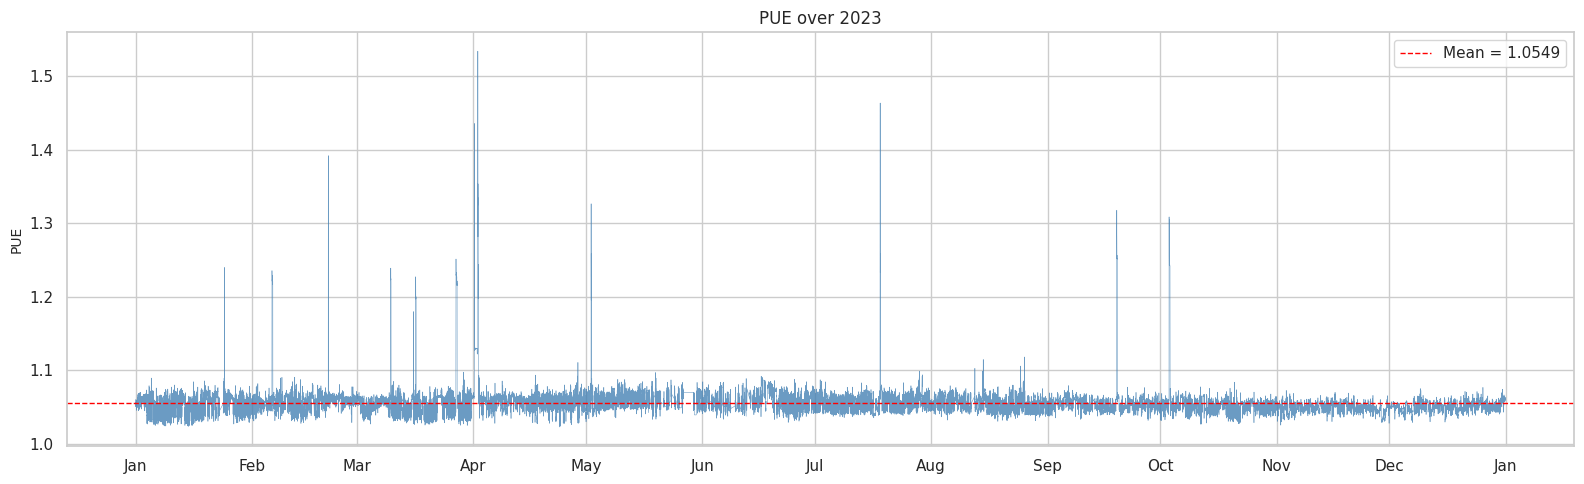

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["timestamp"], df["pue"], lw=0.4, color="steelblue", alpha=0.8)
ax.set_title("PUE over 2023")
ax.set_ylabel("PUE")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.axhline(df["pue"].mean(), color="red", ls="--", lw=1,
           label=f"Mean = {df['pue'].mean():.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/eda/03_pue_full_year.png", dpi=150)
plt.show()

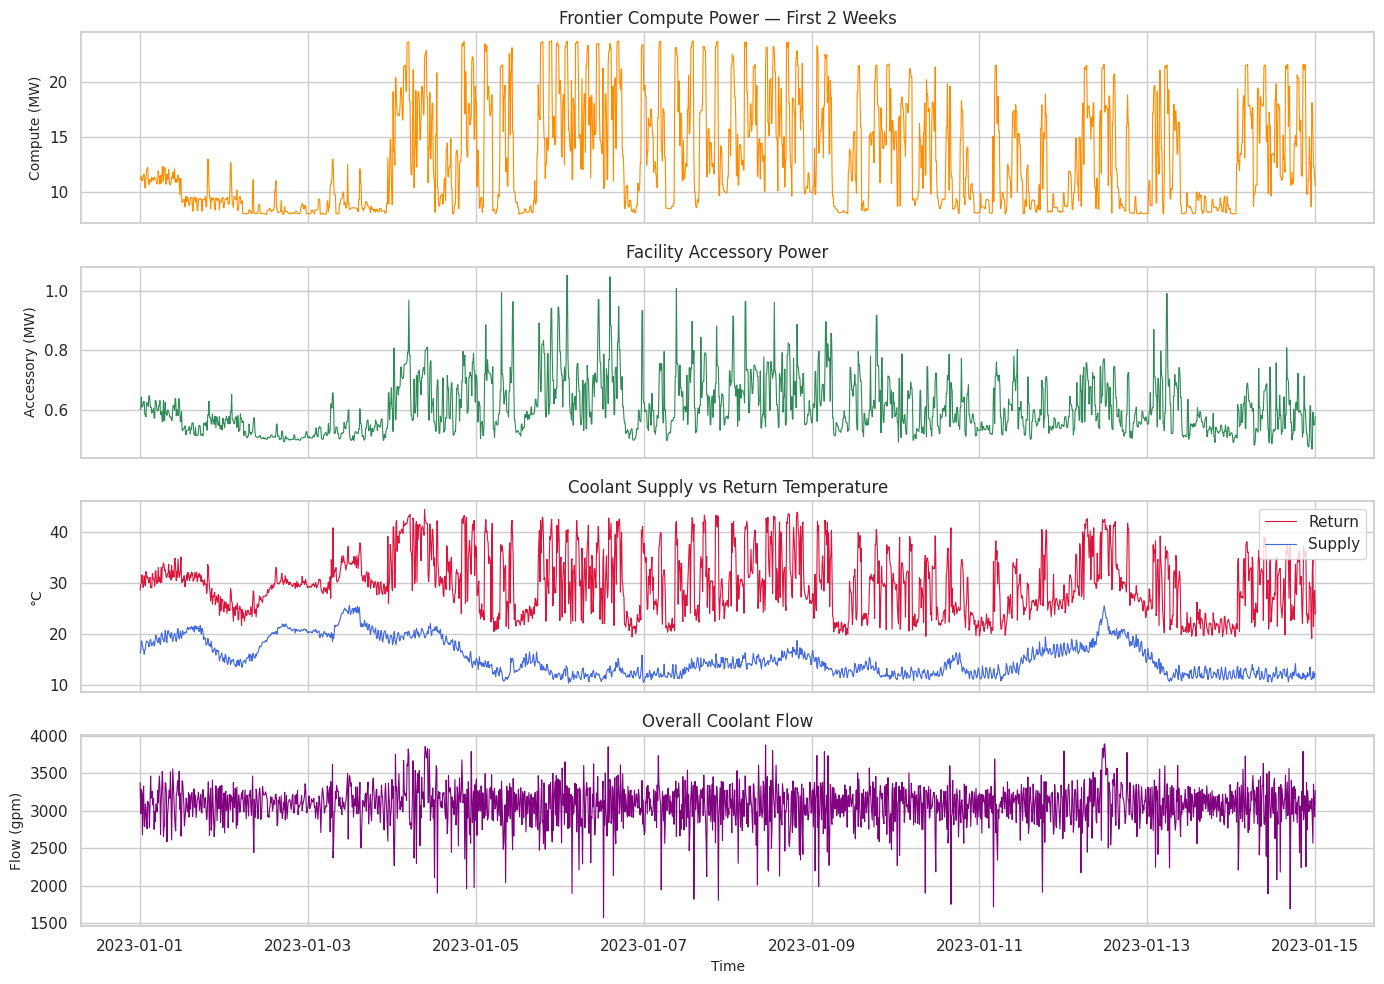

In [8]:
zoom_start = df["timestamp"].min()
zoom_end   = zoom_start + pd.Timedelta(days=14)
sub = df[(df["timestamp"] >= zoom_start) & (df["timestamp"] <= zoom_end)]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sub["timestamp"], sub["compute_power"], lw=0.8, color="darkorange")
axes[0].set_ylabel("Compute (MW)")
axes[0].set_title("Frontier Compute Power — First 2 Weeks")

axes[1].plot(sub["timestamp"], sub["accessory_power"], lw=0.8, color="seagreen")
axes[1].set_ylabel("Accessory (MW)")
axes[1].set_title("Facility Accessory Power")

axes[2].plot(sub["timestamp"], sub["avg_return_temp"], lw=0.8, color="crimson", label="Return")
axes[2].plot(sub["timestamp"], sub["supply_temp"], lw=0.8, color="royalblue", label="Supply")
axes[2].set_ylabel("°C")
axes[2].set_title("Coolant Supply vs Return Temperature")
axes[2].legend(loc="upper right")

axes[3].plot(sub["timestamp"], sub["total_flow"], lw=0.8, color="purple")
axes[3].set_ylabel("Flow (gpm)")
axes[3].set_title("Overall Coolant Flow")
axes[3].set_xlabel("Time")

plt.tight_layout()
plt.savefig("../figures/eda/04_key_signals_2weeks.png", dpi=150)
plt.show()

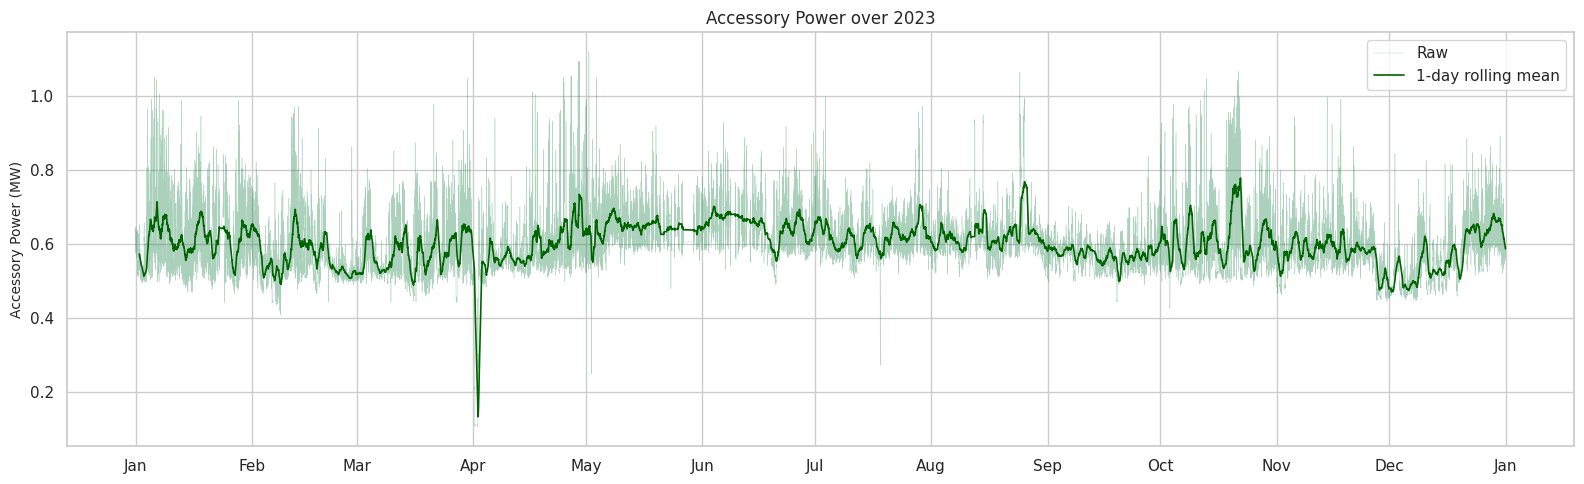

In [9]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["timestamp"], df["accessory_power"], lw=0.3, color="seagreen", alpha=0.4, label="Raw")
rolling = df["accessory_power"].rolling(144).mean()  # 1-day rolling (144 * 10 min)
ax.plot(df["timestamp"], rolling, lw=1.2, color="darkgreen", label="1-day rolling mean")
ax.set_title("Accessory Power over 2023")
ax.set_ylabel("Accessory Power (MW)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend()
plt.tight_layout()
plt.savefig("../figures/eda/05_accessory_power_year.png", dpi=150)
plt.show()

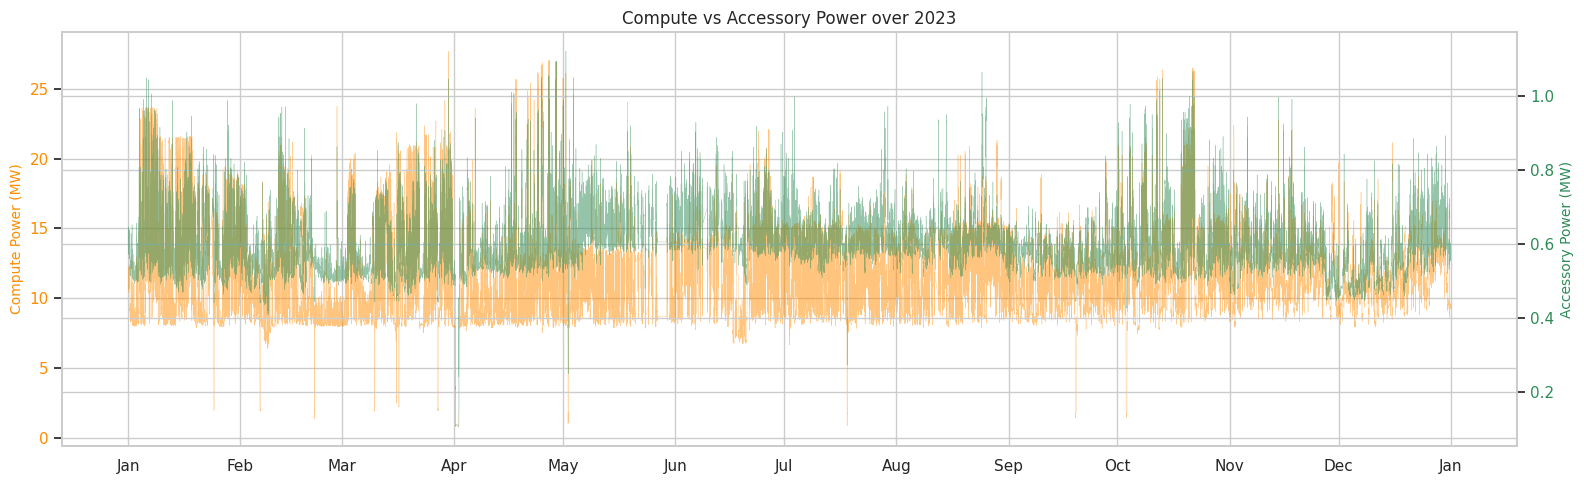

In [10]:
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(df["timestamp"], df["compute_power"], lw=0.3, color="darkorange", alpha=0.5)
ax1.set_ylabel("Compute Power (MW)", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")

ax2 = ax1.twinx()
ax2.plot(df["timestamp"], df["accessory_power"], lw=0.3, color="seagreen", alpha=0.5)
ax2.set_ylabel("Accessory Power (MW)", color="seagreen")
ax2.tick_params(axis="y", labelcolor="seagreen")

ax1.set_title("Compute vs Accessory Power over 2023")
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.savefig("../figures/eda/06_compute_vs_accessory_year.png", dpi=150)
plt.show()

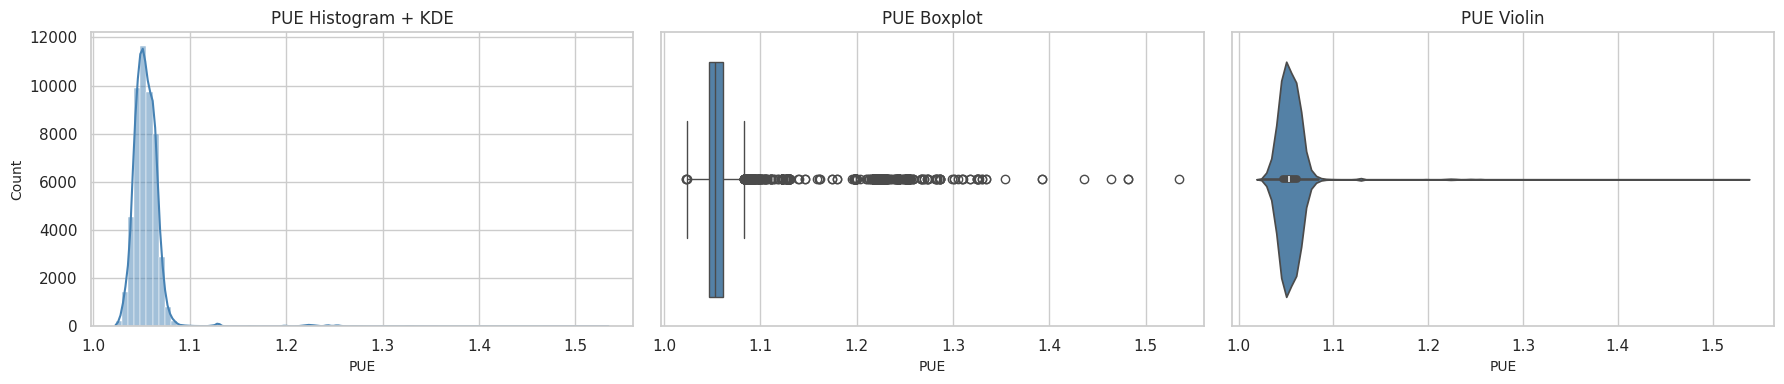

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["pue"], bins=80, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("PUE Histogram + KDE")
axes[0].set_xlabel("PUE")

sns.boxplot(x=df["pue"], ax=axes[1], color="steelblue")
axes[1].set_title("PUE Boxplot")
axes[1].set_xlabel("PUE")

sns.violinplot(x=df["pue"], ax=axes[2], color="steelblue")
axes[2].set_title("PUE Violin")
axes[2].set_xlabel("PUE")

plt.tight_layout()
plt.savefig("../figures/eda/07_pue_distribution.png", dpi=150)
plt.show()

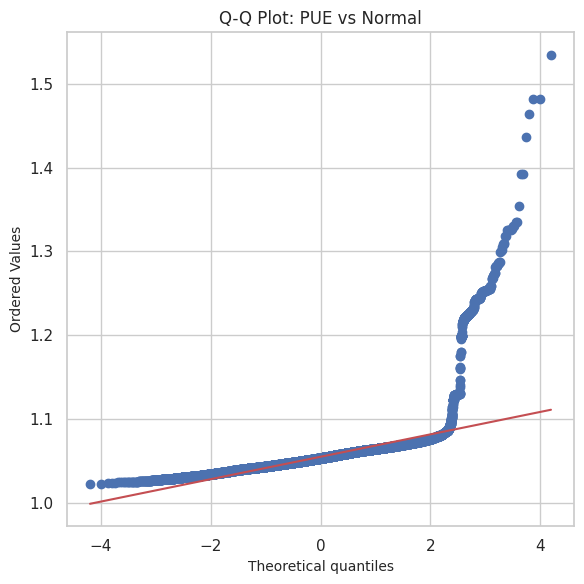

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df["pue"].dropna(), dist="norm", plot=ax)
ax.set_title("Q-Q Plot: PUE vs Normal")
plt.tight_layout()
plt.savefig("../figures/eda/08_pue_qq.png", dpi=150)
plt.show()

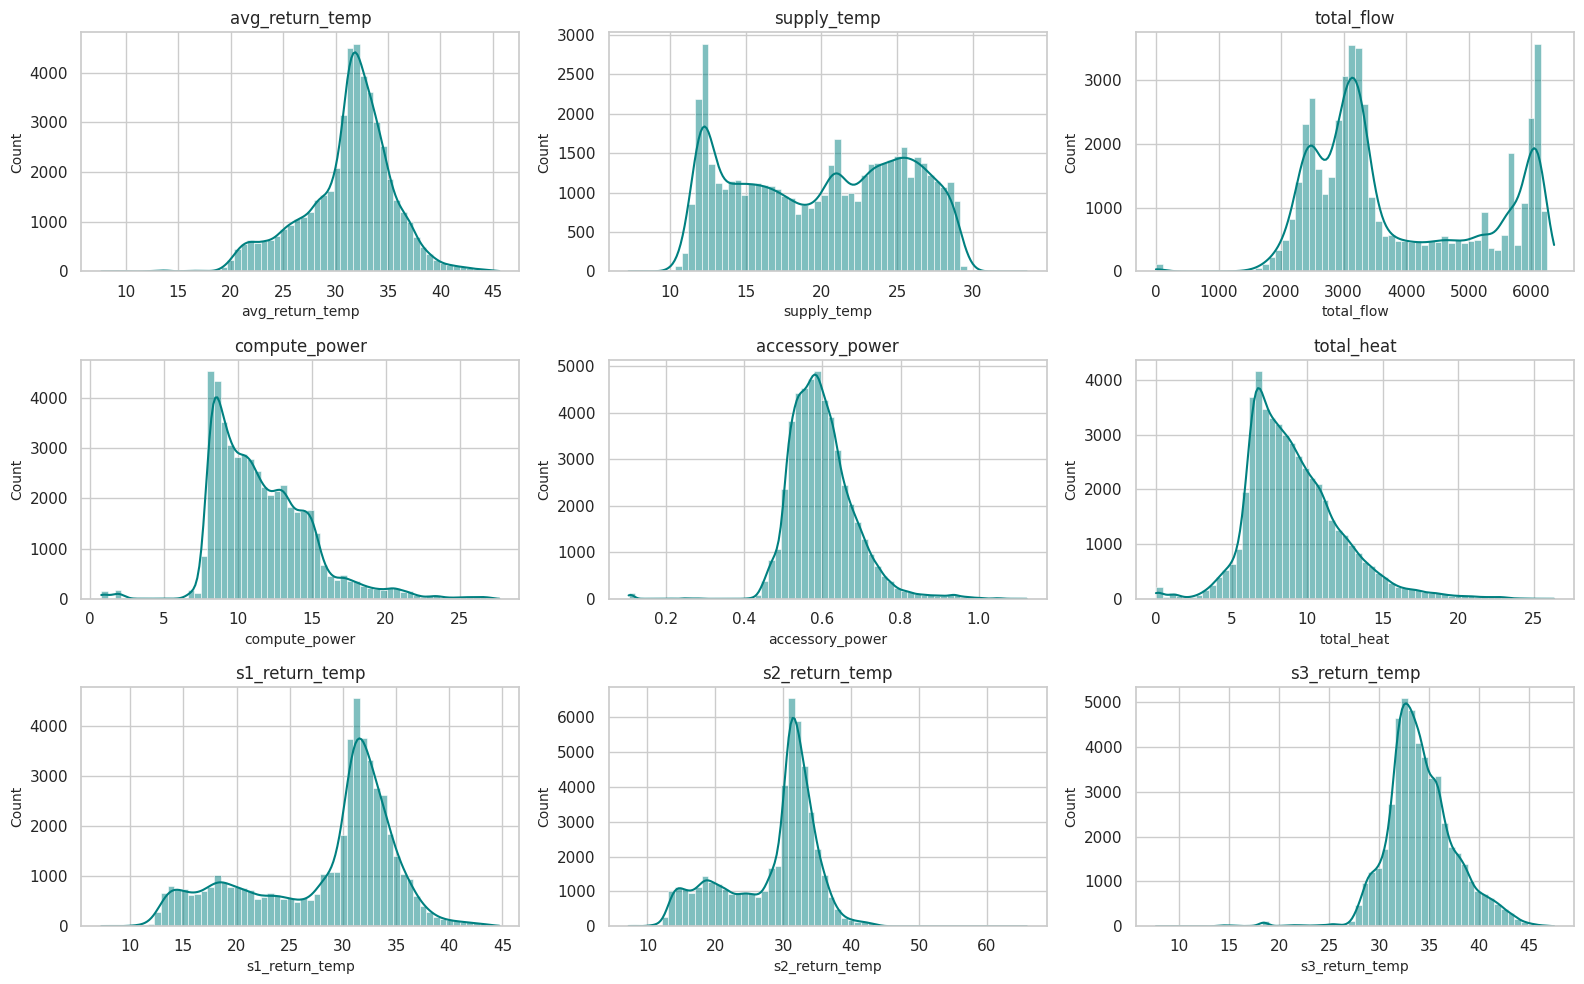

In [13]:
cols = ["avg_return_temp", "supply_temp", "total_flow",
        "compute_power", "accessory_power", "total_heat",
        "s1_return_temp", "s2_return_temp", "s3_return_temp"]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, c in zip(axes.ravel(), cols):
    sns.histplot(df[c].dropna(), bins=60, color="teal", ax=ax, kde=True)
    ax.set_title(c)
plt.tight_layout()
plt.savefig("../figures/eda/09_feature_hists_grid.png", dpi=150)
plt.show()

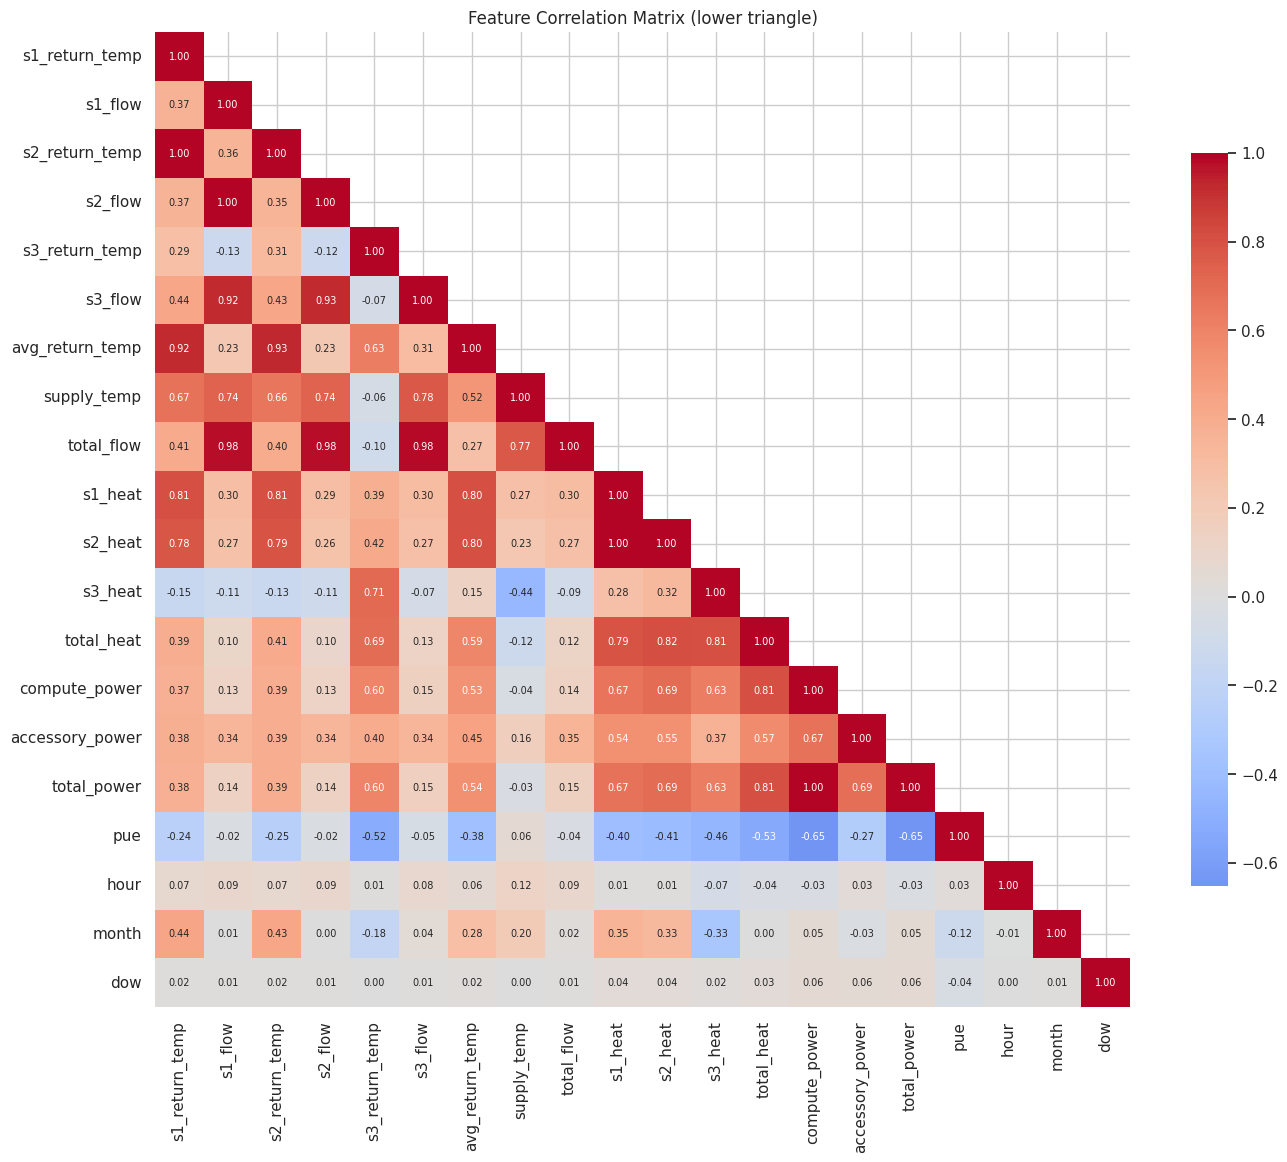

In [14]:
numeric = df.select_dtypes(include=np.number)
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.savefig("../figures/eda/10_correlation_full.png", dpi=150)
plt.show()

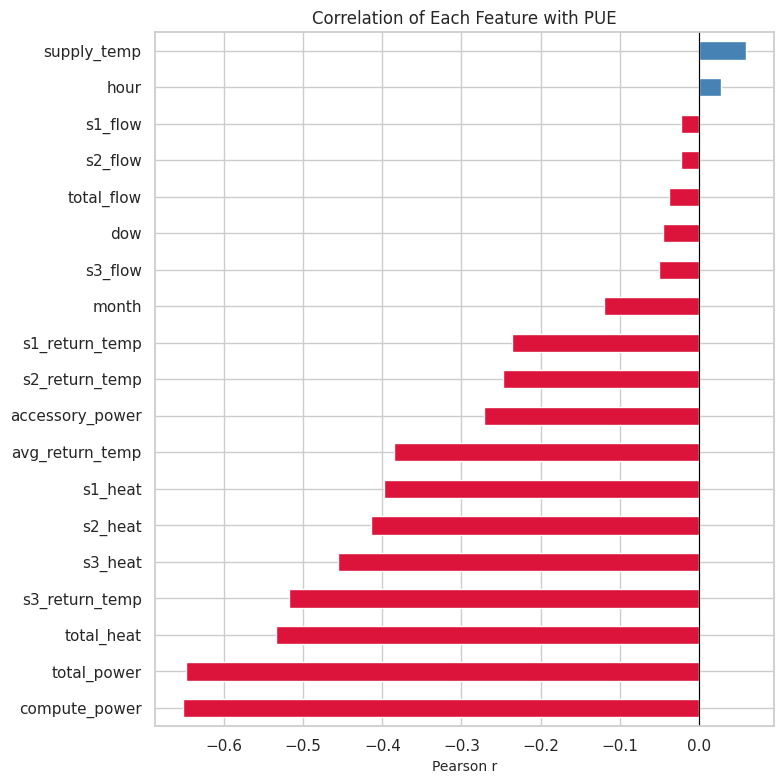

compute_power     -0.652
total_power       -0.648
total_heat        -0.535
s3_return_temp    -0.518
s3_heat           -0.456
s2_heat           -0.414
s1_heat           -0.398
avg_return_temp   -0.385
accessory_power   -0.271
s2_return_temp    -0.247
s1_return_temp    -0.236
month             -0.120
s3_flow           -0.050
dow               -0.045
total_flow        -0.038
s2_flow           -0.023
s1_flow           -0.022
hour               0.028
supply_temp        0.059
Name: pue, dtype: float64


In [15]:
corr_pue = numeric.corr()["pue"].drop("pue").sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_pue]
corr_pue.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation of Each Feature with PUE")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig("../figures/eda/11_pue_correlations.png", dpi=150)
plt.show()

print(corr_pue.round(3))

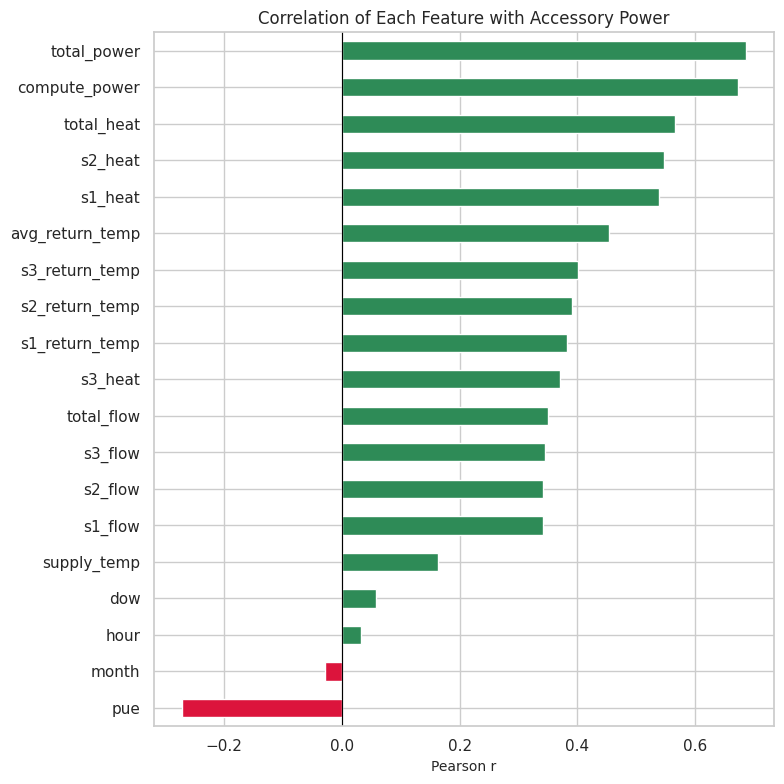

In [16]:
corr_acc = numeric.corr()["accessory_power"].drop("accessory_power").sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["crimson" if v < 0 else "seagreen" for v in corr_acc]
corr_acc.plot(kind="barh", color=colors, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation of Each Feature with Accessory Power")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig("../figures/eda/12_accessory_correlations.png", dpi=150)
plt.show()

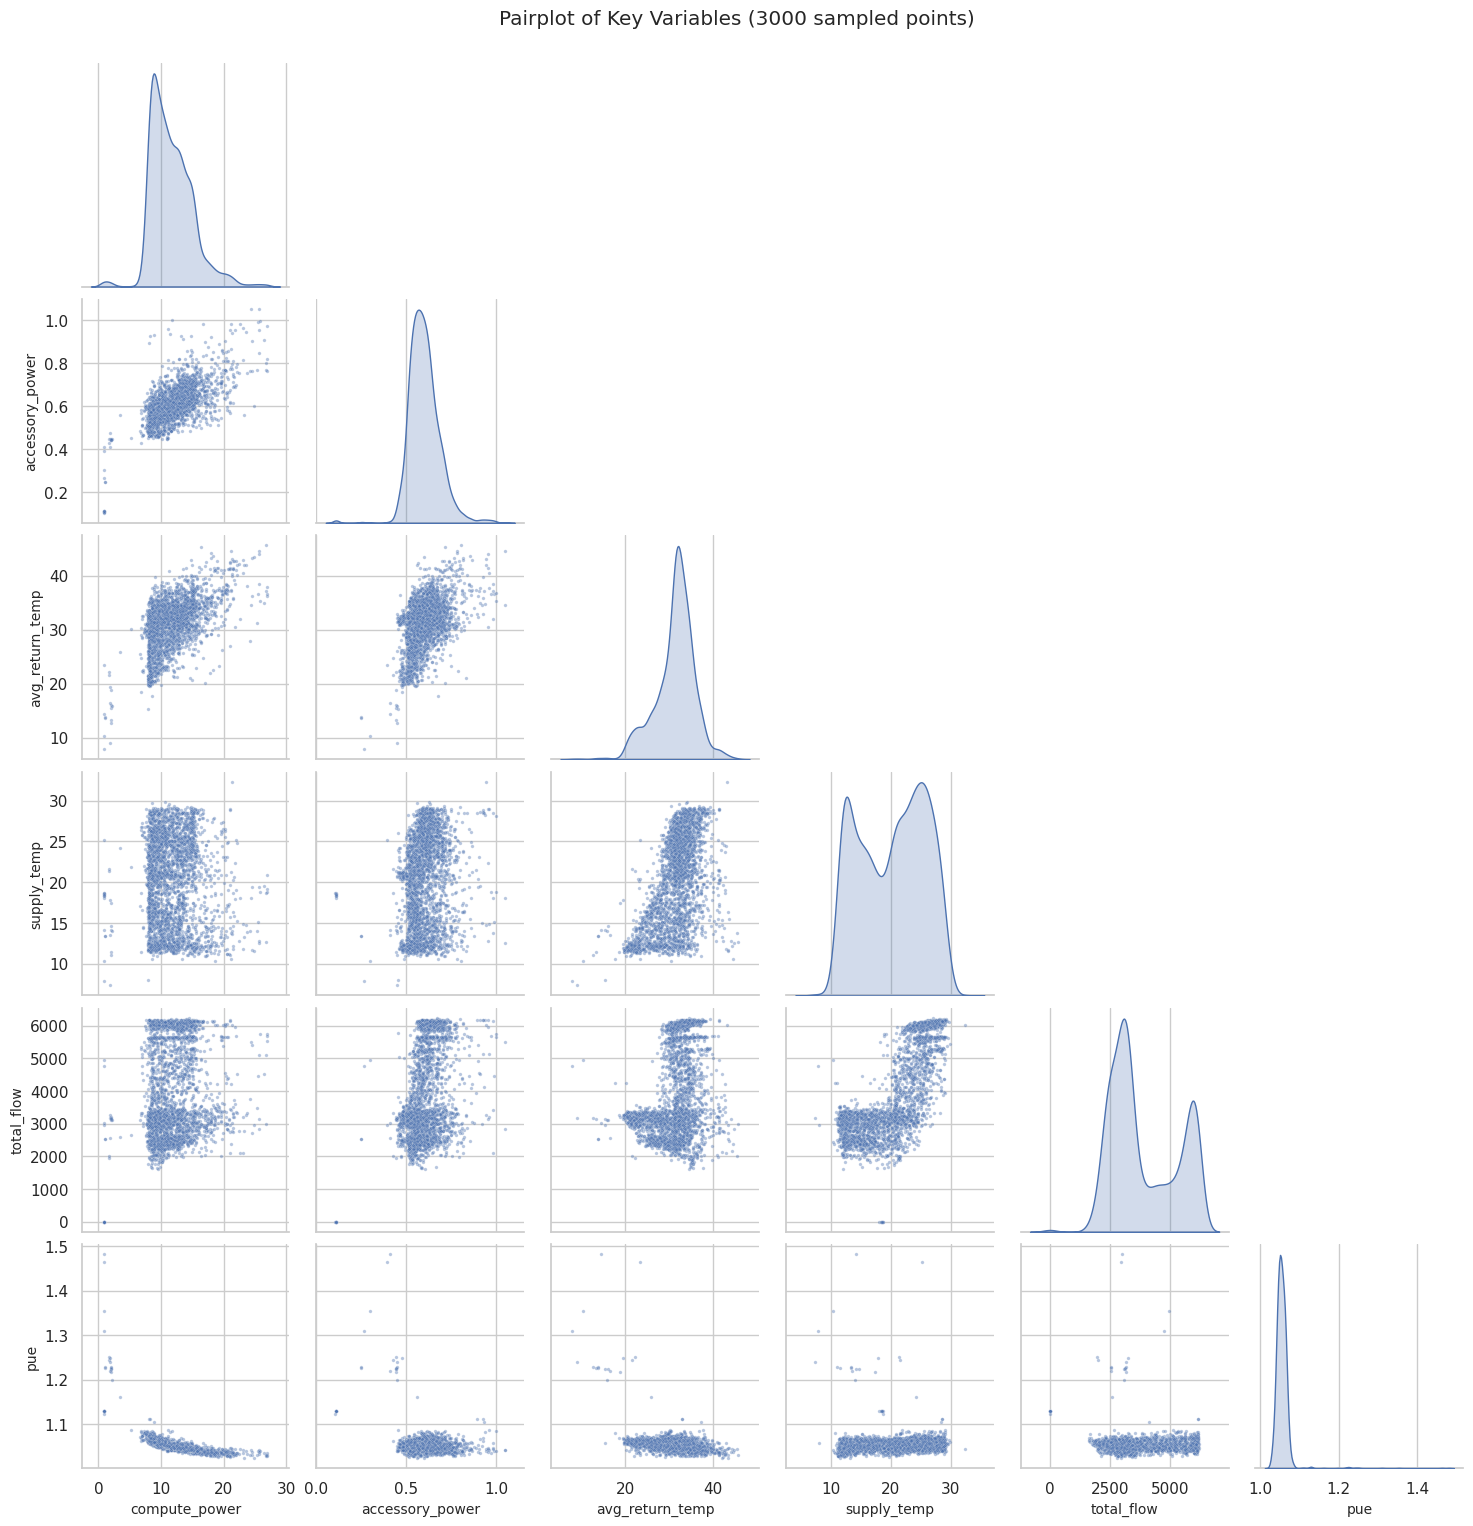

In [17]:
sample = df[["compute_power", "accessory_power", "avg_return_temp",
             "supply_temp", "total_flow", "pue"]].sample(3000, random_state=42)

g = sns.pairplot(sample, corner=True, diag_kind="kde",
                 plot_kws={"s": 6, "alpha": 0.4})
g.fig.suptitle("Pairplot of Key Variables (3000 sampled points)", y=1.02)
plt.savefig("../figures/eda/13_pairplot.png", dpi=150)
plt.show()

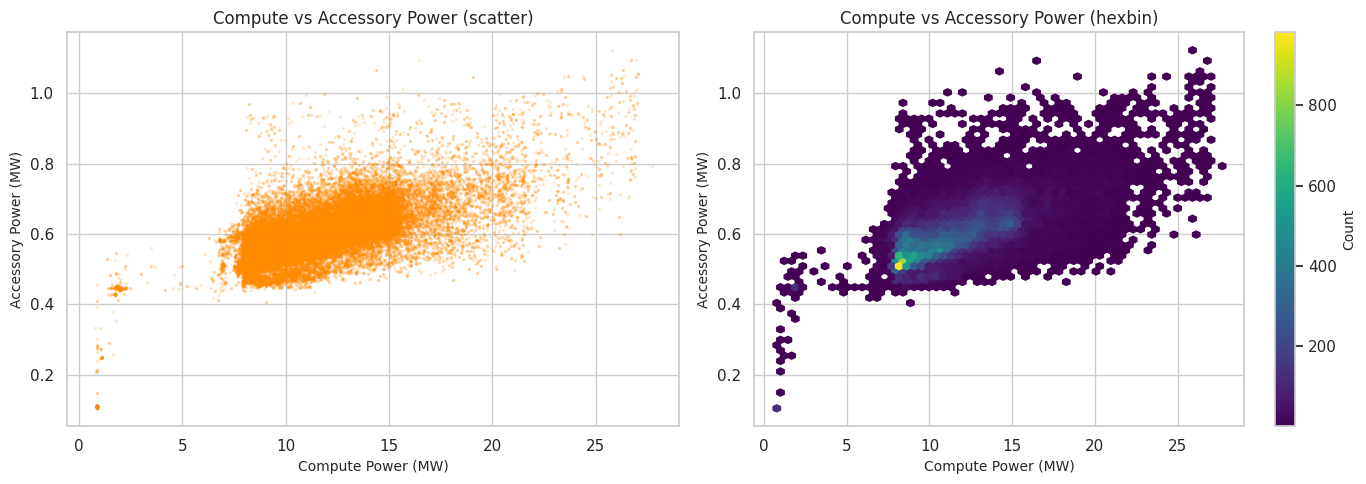

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["compute_power"], df["accessory_power"], s=2, alpha=0.15, color="darkorange")
axes[0].set_xlabel("Compute Power (MW)")
axes[0].set_ylabel("Accessory Power (MW)")
axes[0].set_title("Compute vs Accessory Power (scatter)")

hb = axes[1].hexbin(df["compute_power"], df["accessory_power"],
                    gridsize=60, cmap="viridis", mincnt=1)
axes[1].set_xlabel("Compute Power (MW)")
axes[1].set_ylabel("Accessory Power (MW)")
axes[1].set_title("Compute vs Accessory Power (hexbin)")
fig.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.savefig("../figures/eda/14_compute_vs_accessory.png", dpi=150)
plt.show()

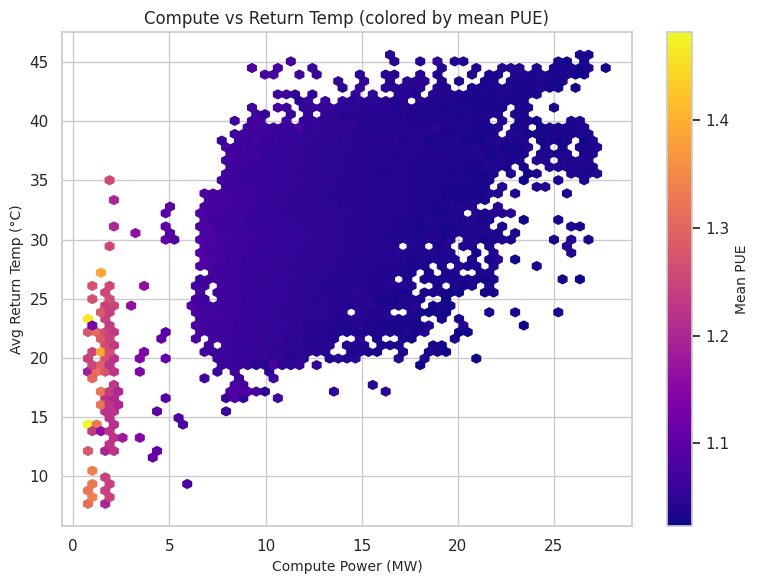

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(df["compute_power"], df["avg_return_temp"],
               C=df["pue"], gridsize=60, cmap="plasma", reduce_C_function=np.mean, mincnt=1)
ax.set_xlabel("Compute Power (MW)")
ax.set_ylabel("Avg Return Temp (°C)")
ax.set_title("Compute vs Return Temp (colored by mean PUE)")
cb = fig.colorbar(hb, ax=ax, label="Mean PUE")
plt.tight_layout()
plt.savefig("../figures/eda/15_compute_vs_returntemp.png", dpi=150)
plt.show()

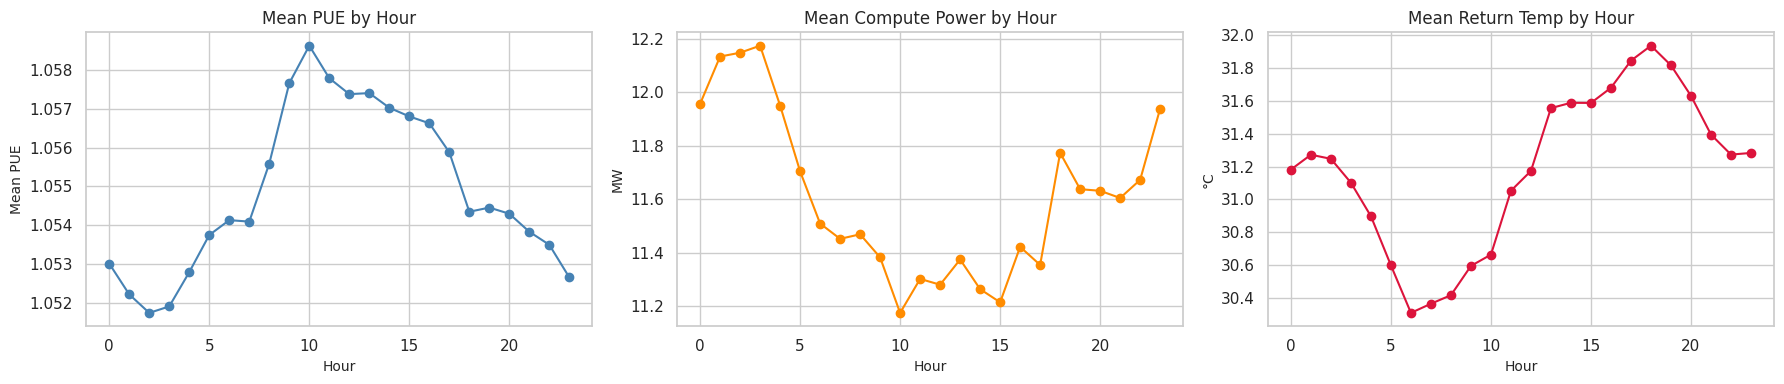

In [20]:
df["hour"] = df["timestamp"].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df.groupby("hour")["pue"].mean().plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Mean PUE by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean PUE")

df.groupby("hour")["compute_power"].mean().plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Mean Compute Power by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("MW")

df.groupby("hour")["avg_return_temp"].mean().plot(ax=axes[2], marker="o", color="crimson")
axes[2].set_title("Mean Return Temp by Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("°C")

plt.tight_layout()
plt.savefig("../figures/eda/16_hourly_averages.png", dpi=150)
plt.show()

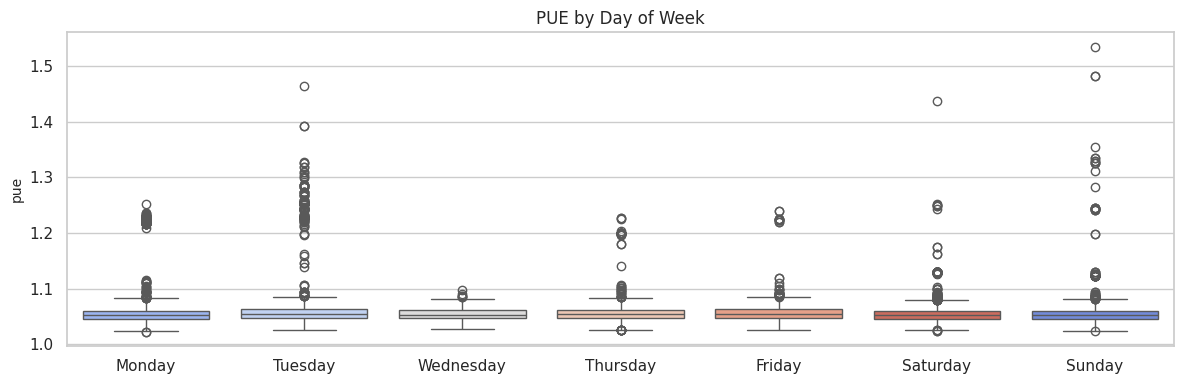

In [21]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["dow_name"] = df["timestamp"].dt.day_name()

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df, x="dow_name", y="pue", order=order,
            hue="dow_name", legend=False,
            palette="coolwarm", ax=ax)
ax.set_title("PUE by Day of Week")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../figures/eda/17_dow_boxplot.png", dpi=150)
plt.show()

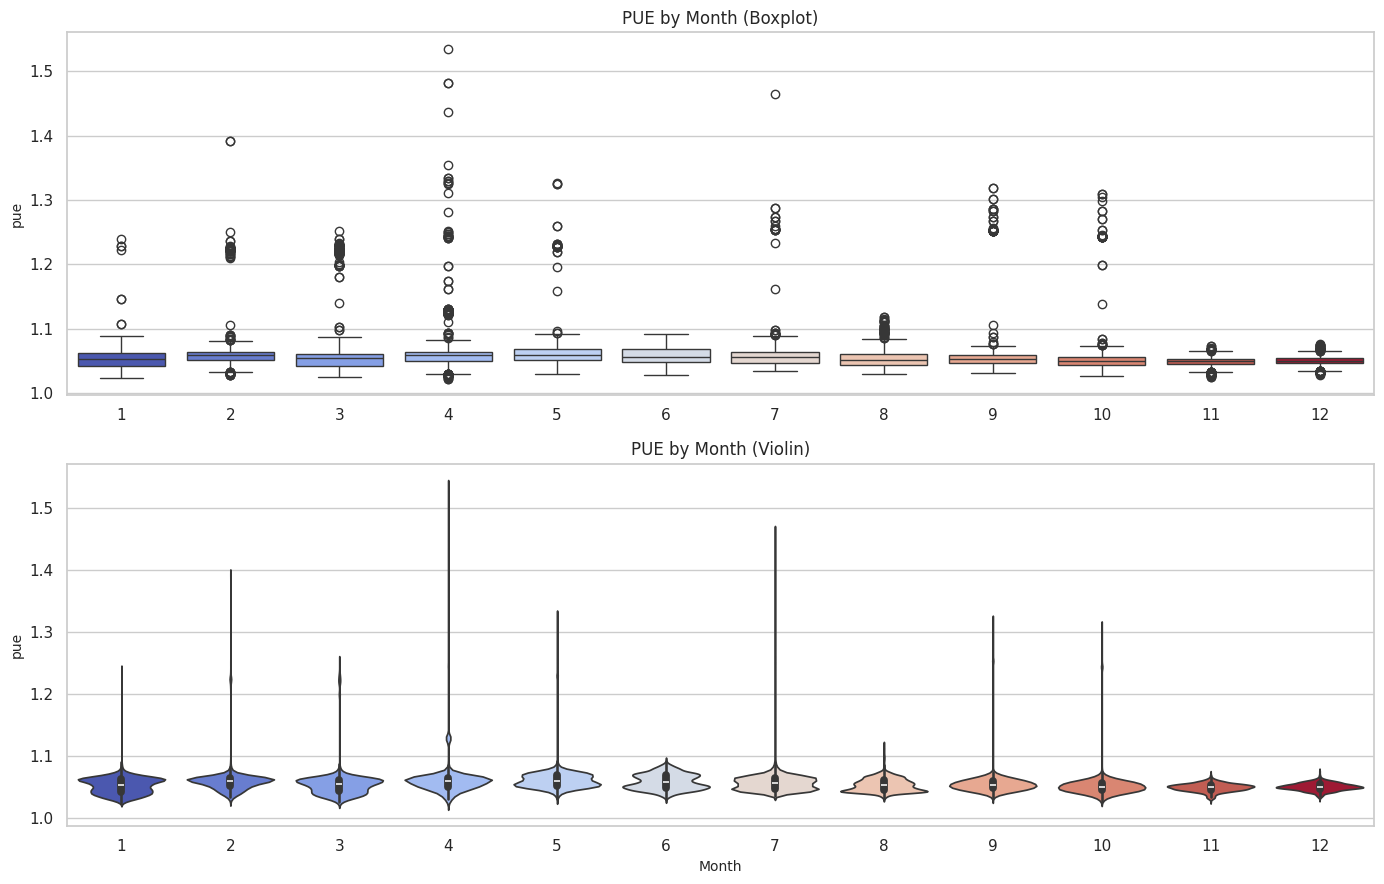

In [22]:
# Ensure time columns exist
df["hour"]      = df["timestamp"].dt.hour
df["month"]     = df["timestamp"].dt.month
df["dow"]       = df["timestamp"].dt.dayofweek
df["dow_name"]  = df["timestamp"].dt.day_name()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.boxplot(data=df, x="month", y="pue",
            hue="month", legend=False, palette="coolwarm", ax=axes[0])
axes[0].set_title("PUE by Month (Boxplot)")
axes[0].set_xlabel("")

sns.violinplot(data=df, x="month", y="pue",
               hue="month", legend=False, palette="coolwarm", ax=axes[1])
axes[1].set_title("PUE by Month (Violin)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.savefig("../figures/eda/18_monthly_distributions.png", dpi=150)
plt.show()

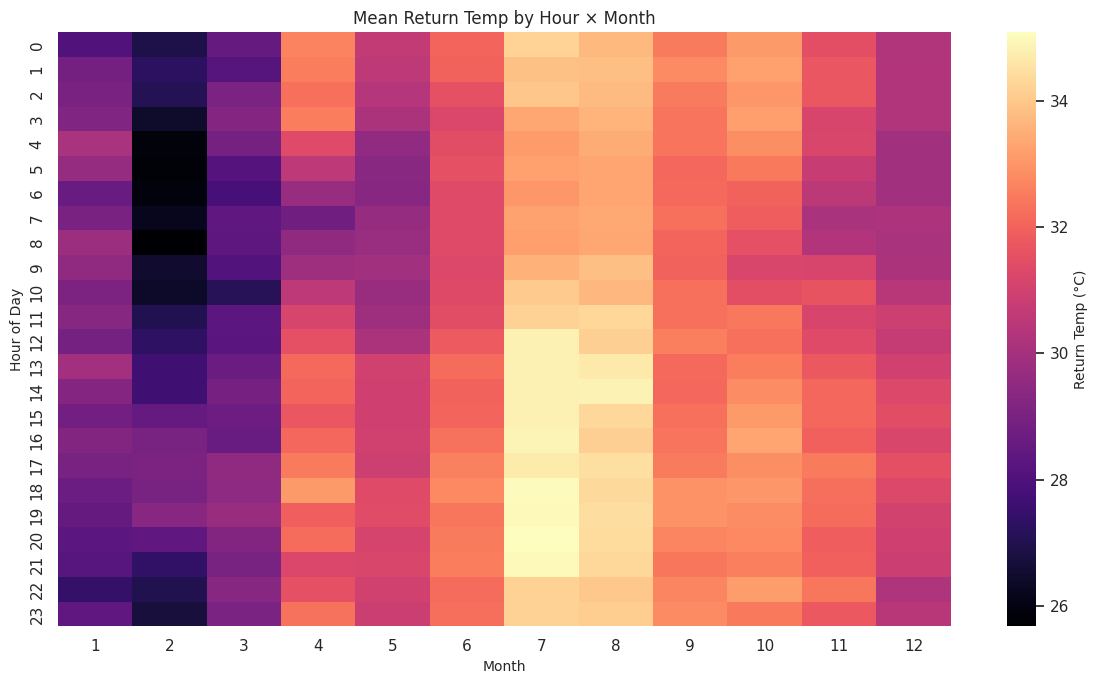

In [23]:
df["hour"]  = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month

pivot2 = df.pivot_table(index="hour", columns="month", values="avg_return_temp", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot2, cmap="magma", cbar_kws={"label": "Return Temp (°C)"}, ax=ax)
ax.set_title("Mean Return Temp by Hour × Month")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("../figures/eda/20_returntemp_heatmap.png", dpi=150)
plt.show()

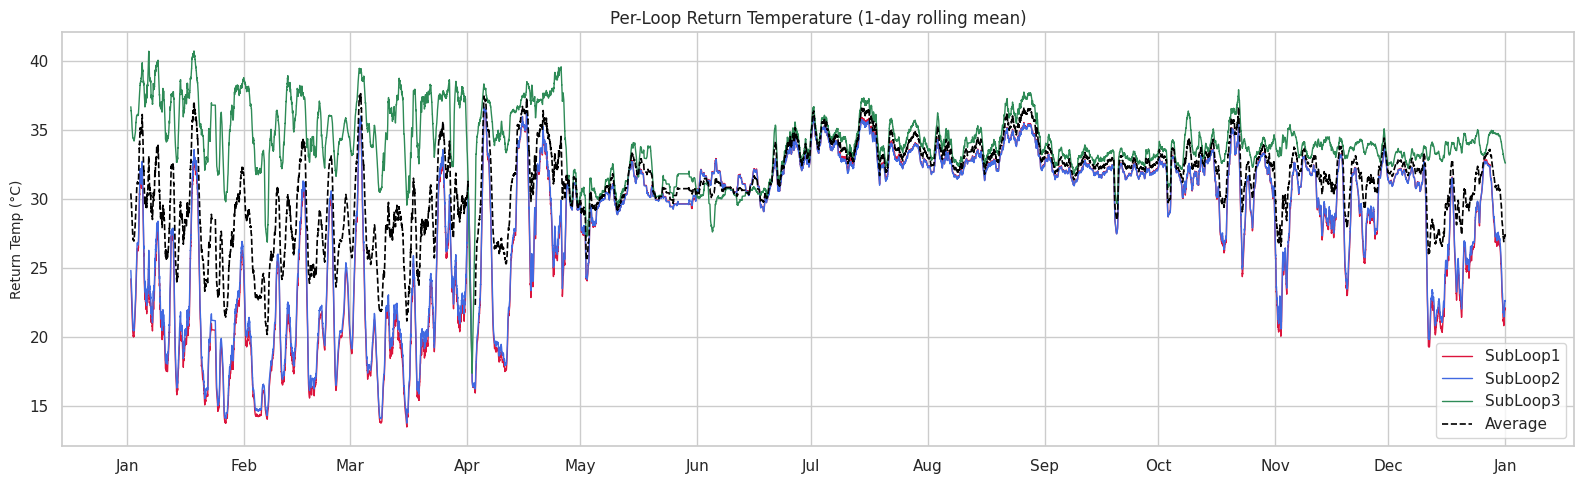

In [24]:
fig, ax = plt.subplots(figsize=(16, 5))
for i, c in zip([1, 2, 3], ["crimson", "royalblue", "seagreen"]):
    s = df[f"s{i}_return_temp"].rolling(144).mean()
    ax.plot(df["timestamp"], s, lw=1, color=c, label=f"SubLoop{i}")

ax.plot(df["timestamp"], df["avg_return_temp"].rolling(144).mean(),
        lw=1.2, color="black", ls="--", label="Average")
ax.set_ylabel("Return Temp (°C)")
ax.set_title("Per-Loop Return Temperature (1-day rolling mean)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend()
plt.tight_layout()
plt.savefig("../figures/eda/21_per_loop_temps.png", dpi=150)
plt.show()

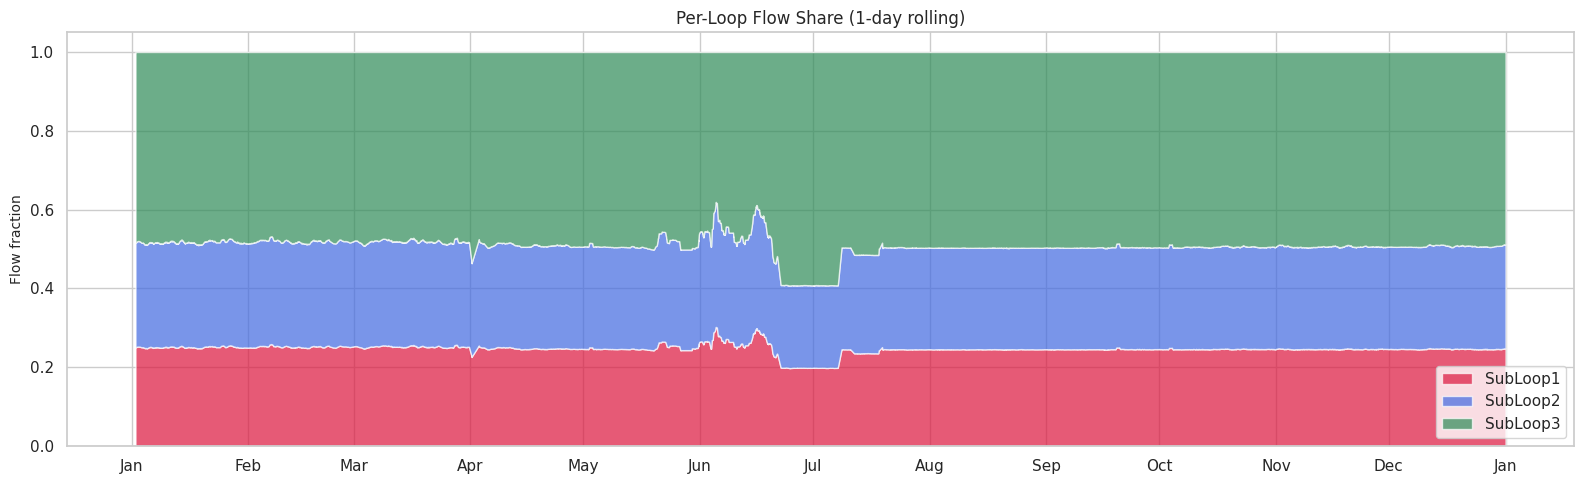

In [25]:
shares = df[["s1_flow", "s2_flow", "s3_flow"]].div(df["total_flow"], axis=0)
shares = shares.rolling(144).mean()
shares = shares.dropna()

fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(df["timestamp"].iloc[shares.index], shares.T,
             labels=["SubLoop1", "SubLoop2", "SubLoop3"],
             colors=["crimson", "royalblue", "seagreen"], alpha=0.7)
ax.set_ylabel("Flow fraction")
ax.set_title("Per-Loop Flow Share (1-day rolling)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/eda/22_flow_share.png", dpi=150)
plt.show()

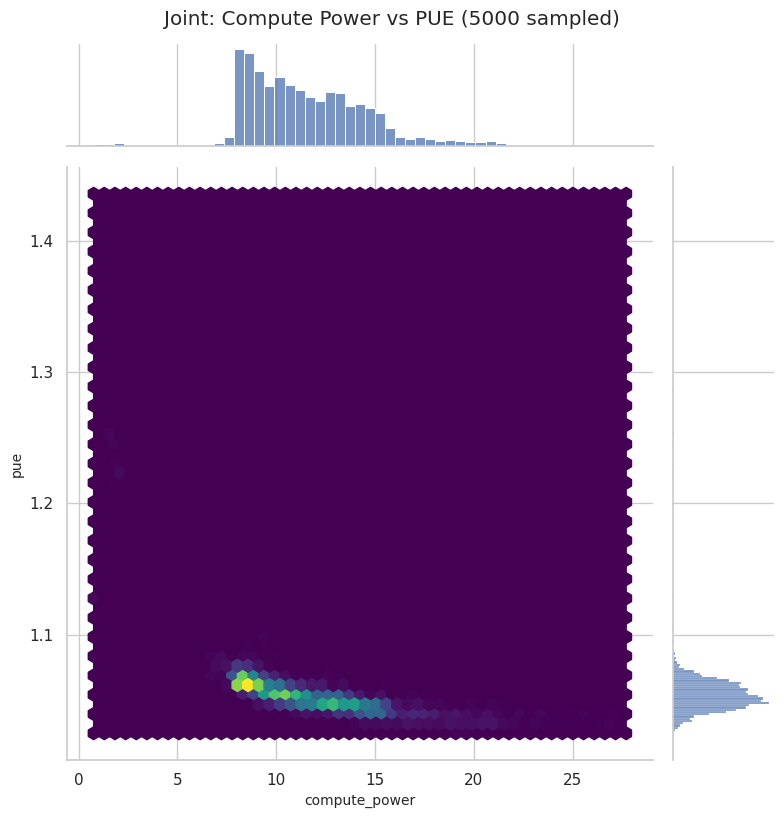

In [26]:
g = sns.jointplot(data=df.sample(5000, random_state=0),
                  x="compute_power", y="pue",
                  kind="hex", height=8, cmap="viridis", gridsize=50)
g.fig.suptitle("Joint: Compute Power vs PUE (5000 sampled)", y=1.02)
g.savefig("../figures/eda/23_joint_compute_pue.png", dpi=150)
plt.show()

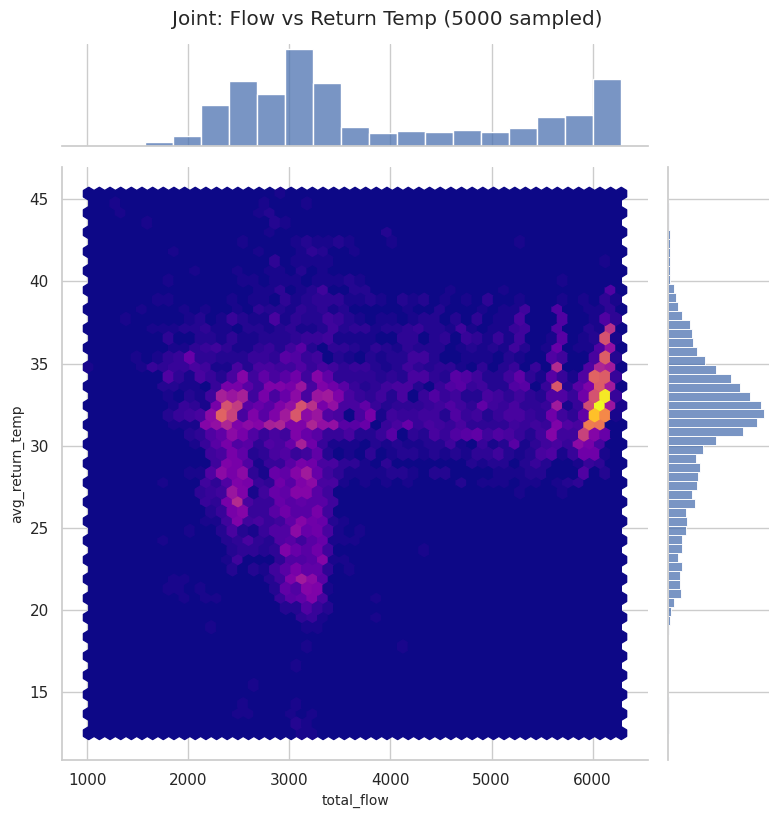

In [27]:
g = sns.jointplot(data=df.sample(5000, random_state=0),
                  x="total_flow", y="avg_return_temp",
                  kind="hex", height=8, cmap="plasma", gridsize=50)
g.fig.suptitle("Joint: Flow vs Return Temp (5000 sampled)", y=1.02)
g.savefig("../figures/eda/24_joint_flow_temp.png", dpi=150)
plt.show()

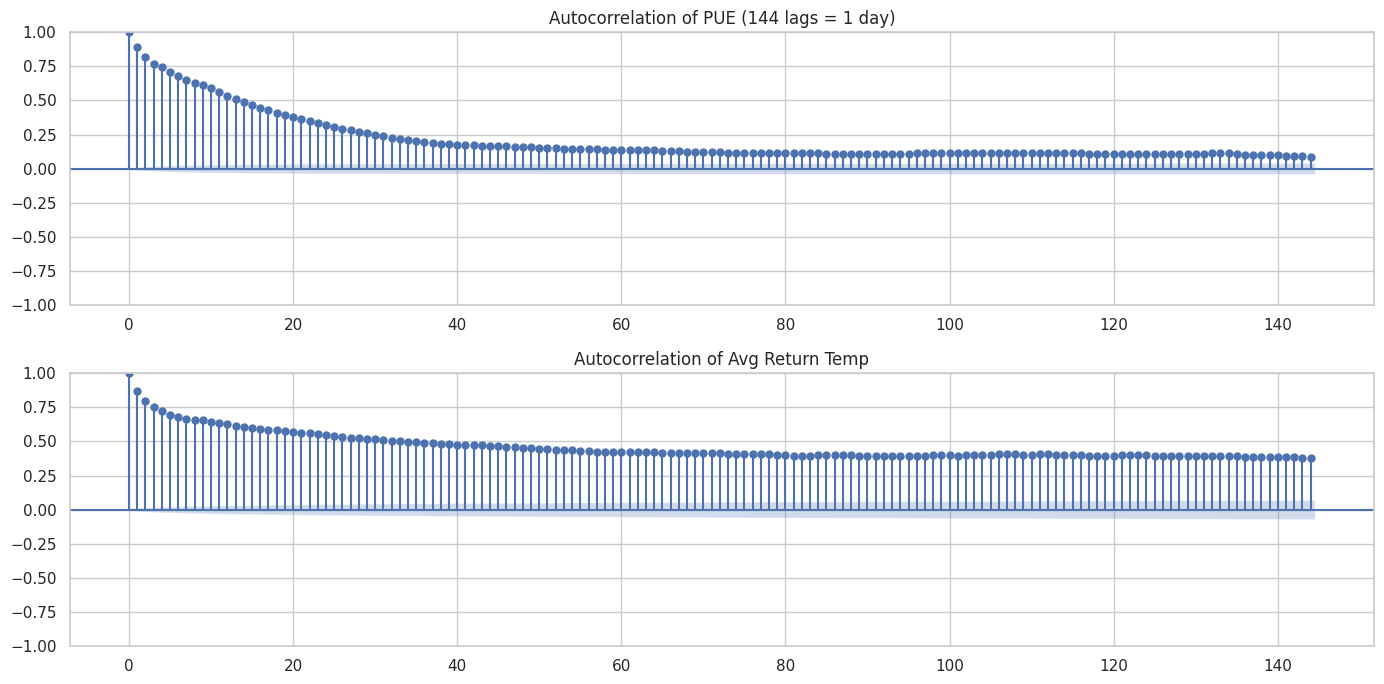

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(df["pue"].dropna(), lags=144, ax=axes[0])   # 1 day of lags
axes[0].set_title("Autocorrelation of PUE (144 lags = 1 day)")
plot_acf(df["avg_return_temp"].dropna(), lags=144, ax=axes[1])
axes[1].set_title("Autocorrelation of Avg Return Temp")
plt.tight_layout()
plt.savefig("../figures/eda/25_autocorrelation.png", dpi=150)
plt.show()

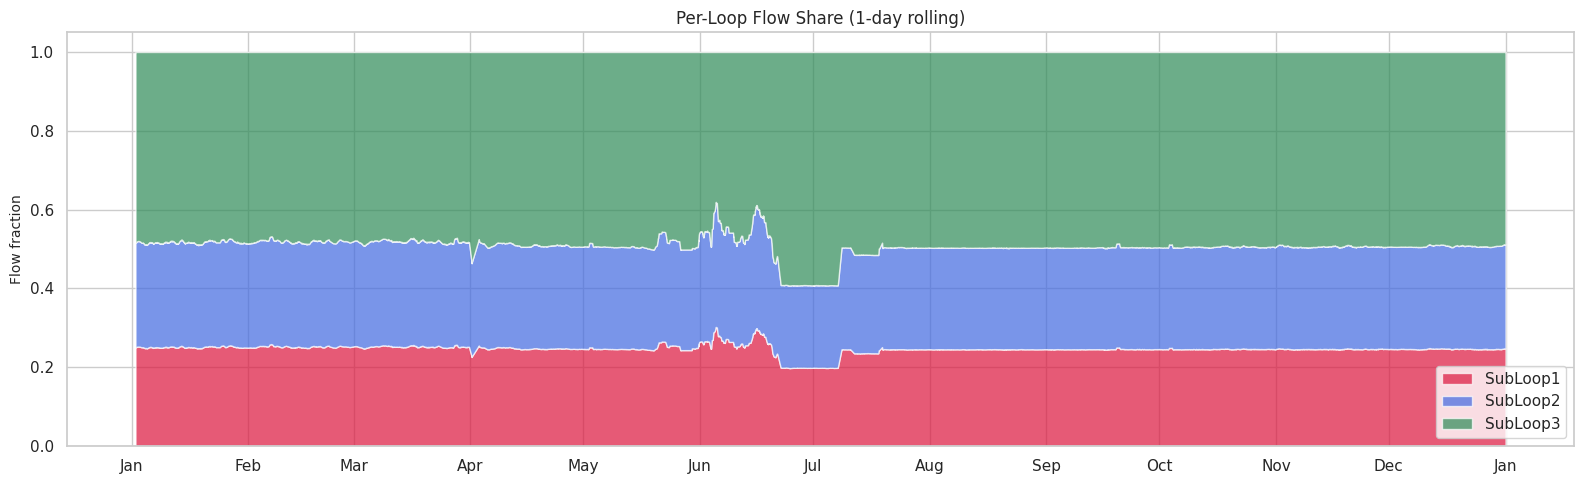

In [29]:
shares = df[["s1_flow", "s2_flow", "s3_flow"]].div(df["total_flow"], axis=0)
shares = shares.rolling(144).mean()
shares = shares.dropna()

fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(df["timestamp"].iloc[shares.index], shares.T,
             labels=["SubLoop1", "SubLoop2", "SubLoop3"],
             colors=["crimson", "royalblue", "seagreen"], alpha=0.7)
ax.set_ylabel("Flow fraction")
ax.set_title("Per-Loop Flow Share (1-day rolling)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/eda/22_flow_share.png", dpi=150)
plt.show()

In [30]:
print("PUE < 1:                ", (df["pue"] < 1).sum())
print("Return <= Supply:       ", (df["avg_return_temp"] <= df["supply_temp"]).sum())
print("Negative flows:         ", (df[["s1_flow","s2_flow","s3_flow","total_flow"]] < 0).any(axis=1).sum())
print("Zero compute power:     ", (df["compute_power"] <= 0).sum())
print("Return temp > 60 °C:    ", (df["avg_return_temp"] > 60).sum())
print("PUE > 2:                ", (df["pue"] > 2).sum())
print("Supply temp > Return:   ", (df["supply_temp"] > df["avg_return_temp"]).sum())

PUE < 1:                 0
Return <= Supply:        68
Negative flows:          0
Zero compute power:      0
Return temp > 60 °C:     0
PUE > 2:                 0
Supply temp > Return:    68


In [31]:
summary = {
    "records": len(df),
    "start": str(df["timestamp"].min()),
    "end": str(df["timestamp"].max()),
    "mean_pue": round(df["pue"].mean(), 4),
    "min_pue": round(df["pue"].min(), 4),
    "max_pue": round(df["pue"].max(), 4),
    "mean_compute_MW": round(df["compute_power"].mean(), 3),
    "mean_accessory_MW": round(df["accessory_power"].mean(), 3),
    "mean_return_temp_C": round(df["avg_return_temp"].mean(), 2),
    "mean_supply_temp_C": round(df["supply_temp"].mean(), 2),
    "missing_avg_return_temp": int(df["avg_return_temp"].isna().sum()),
}

for k, v in summary.items():
    print(f"{k:30s} {v}")

records                        49869
start                          2023-01-01 00:00:00
end                            2023-12-31 23:50:00
mean_pue                       1.0549
min_pue                        1.0229
max_pue                        1.5345
mean_compute_MW                11.603
mean_accessory_MW              0.598
mean_return_temp_C             31.2
mean_supply_temp_C             19.98
missing_avg_return_temp        122
